Extracted 110 patches from the image.
Generated 660 total images (original + augmented).


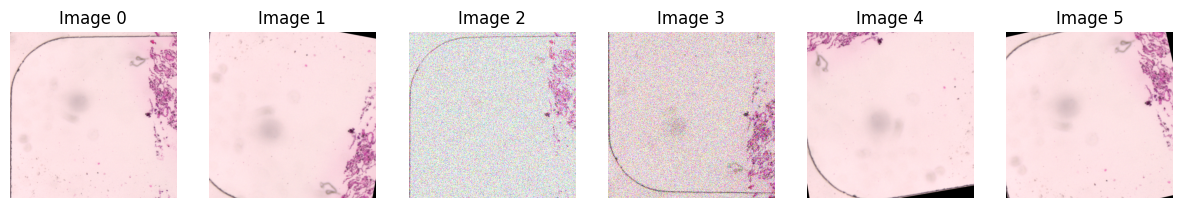

In [ ]:
import cv2
import numpy as np
import albumentations as A
from PIL import Image
import os

#Load the CytAssist Image
image_path = "/content/Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1_image (1).tif"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for consistency

# Normalize pixel values to [0, 1]
image_normalized = image / 255.0

# Define patch size (e.g., 512x512 pixels)
patch_size = 512
patches = []

#Extract Patches from the Image
height, width = image.shape[:2]
for y in range(0, height - patch_size + 1, patch_size // 2):
    for x in range(0, width - patch_size + 1, patch_size // 2):
        patch = image[y:y + patch_size, x:x + patch_size]
        if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
            patches.append(patch)

print(f"Extracted {len(patches)} patches from the image.")

# Define Augmentation Pipeline with Albumentations
augmentation_pipeline = A.Compose([
    A.Rotate(limit=90, p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.RandomCrop(height=448, width=448, p=0.3)
])

# Apply Augmentations and Save Results
output_dir = "augmented_patches"
os.makedirs(output_dir, exist_ok=True)

augmented_images = []
for i, patch in enumerate(patches):
    # Save original patch
    original_patch_path = os.path.join(output_dir, f"patch_{i}_original.png")
    cv2.imwrite(original_patch_path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))
    augmented_images.append(patch)

    # Apply augmentations
    for j in range(5):
        augmented = augmentation_pipeline(image=patch)["image"]
        aug_patch_path = os.path.join(output_dir, f"patch_{i}_aug_{j}.png")
        cv2.imwrite(aug_patch_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
        augmented_images.append(augmented)

print(f"Generated {len(augmented_images)} total images (original + augmented).")


import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for k in range(6):
    plt.subplot(1, 6, k + 1)
    plt.imshow(augmented_images[k])
    plt.axis("off")
    plt.title(f"Image {k}")
plt.show()

In [ ]:
from PIL import Image
image = Image.open(image_path).convert("RGB")
image = np.array(image)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and Prepare the Dataset
image_dir = "augmented_patches"
image_size = (448, 448)
batch_size = 16

def load_images(image_dir):
    images = []
    for filename in os.listdir(image_dir):
        if filename.endswith(".png"):
            img_path = os.path.join(image_dir, filename)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=image_size)
            img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
            images.append(img)
    return np.array(images)

images = load_images(image_dir)
print(f"Loaded {images.shape[0]} images with shape {images.shape[1:]}")

train_images, temp_images = train_test_split(images, test_size=0.3, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)
print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

# Define Feature Extractor (Encoder)
def build_feature_extractor(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu", name="feature_output")  # Feature vector output
    ])
    return model

# Define Full Autoencoder (Encoder + Decoder)
def build_autoencoder_with_feature_extractor(input_shape):
    # Encoder (our feature extractor)
    inputs = layers.Input(shape=input_shape)
    feature_extractor = build_feature_extractor(input_shape)
    encoded = feature_extractor(inputs)  # 256-dim feature vector

    # Reshape the 256-dim vector back to a spatial tensor for decoding
    x = layers.Dense(56 * 56 * 128, activation="relu")(encoded)  # Reverse Flatten
    x = layers.Reshape((56, 56, 128))(x)  # Match shape before Flatten (56x56x128)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)  # 56x56 -> 112x112
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)  # 112x112 -> 224x224
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)  # 224x224 -> 448x448
    decoded = layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)  # Reconstruct RGB image

    # Full autoencoder model
    autoencoder = models.Model(inputs, decoded)
    return autoencoder, feature_extractor

# Compile and Train
input_shape = (448, 448, 3)
autoencoder, feature_model = build_autoencoder_with_feature_extractor(input_shape)
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])
autoencoder.summary()

# Train the autoencoder (trains the feature extractor as part of it)
history = autoencoder.fit(
    train_images, train_images,  # Input = Target for reconstruction
    validation_data=(val_images, val_images),
    epochs=20,
    batch_size=batch_size,
    verbose=1
)

# Extract Features using the trained feature extractor
features = feature_model.predict(train_images)
print(f"Extracted features shape: {features.shape}")

# Visualize Images and Features
num_samples = 5
plt.figure(figsize=(15, 6))
for i in range(num_samples):
    # Original Image
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(train_images[i])
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # Feature Visualization
    plt.subplot(2, num_samples, num_samples + i + 1)
    feature_vector = features[i].reshape(16, 16)  # Reshape 256 to 16x16 for visualization
    plt.imshow(feature_vector, cmap="viridis")
    plt.title(f"Features {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Plot Evaluation Metrics
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss (MSE)")
plt.plot(history.history["val_loss"], label="Val Loss (MSE)")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# Save Models and Features
feature_model.save("trained_feature_extractor.h5")
autoencoder.save("autoencoder.h5")
np.save("extracted_features.npy", features)

Loaded 660 images with shape (448, 448, 3)
Train: 462, Val: 99, Test: 99


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256)            │   102,853,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 401408)         │   103,161,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 448, 448, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 448, 448, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,256,515 (786.81 MB)

 Trainable params: 206,256,515 (786.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 685s 23s/step - loss: 0.0902 - mae: 0.2382 - val_loss: 0.0521 - val_mae: 0.1559
Epoch 2/20


In [ ]:
!pip install torch==2.4.1
!pip install torch-geometric==2.5.3
!pip install anndata==0.10.9 scanpy==1.10.3 pandas==2.2.3 pyarrow==17.0.0 scipy==1.14.1 mygene opencv-python

  Using cached anndata-0.10.9-py3-none-any.whl.metadata (6.9 kB)
  Using cached scanpy-1.10.3-py3-none-any.whl.metadata (9.4 kB)
  Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached pyarrow-17.0.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached legacy_api_wrap-1.4.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached session_info-1.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached biothings_client-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached anndata-0.10.9-py3-none-any.whl (128 kB)
Using cached scanpy-1.10.3-py3-none-any.whl (2.1 MB)
Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached pyarrow-17.0.0-cp311-cp311-manylinux_2_28_x86_64.whl (39.9 MB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
Using cached biothings_client-0.4.1-py3-none-any.whl (46 kB)
Using c

In [ ]:
pip install anndata

  Using cached array_api_compat-1.11.2-py3-none-any.whl.metadata (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 4.3 MB/s eta 0:00:00
Using cached array_api_compat-1.11.2-py3-none-any.whl (53 kB)


In [ ]:
pip install torch

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Before filtering: adata shape = (448109, 18085), coords shape = (448109, 2)
After zero-count filtering: adata size = 447595, coords size = 447595
Image shape: (3000, 3200)
Scaled coords max: [3199.47687775 3053.22898963]
Total spots: 447595, Valid coords: 446943, In tissue: 444103
Filtered to 444103 spots within tissue region.
Subsampled to 8000 spots to reduce memory usage.


INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-18085 ...
INFO:biothings.client:Finished.


Loaded CNN features shape: (462, 256)
Combined features shape: (8000, 261), CNN: 256, Genes: 5


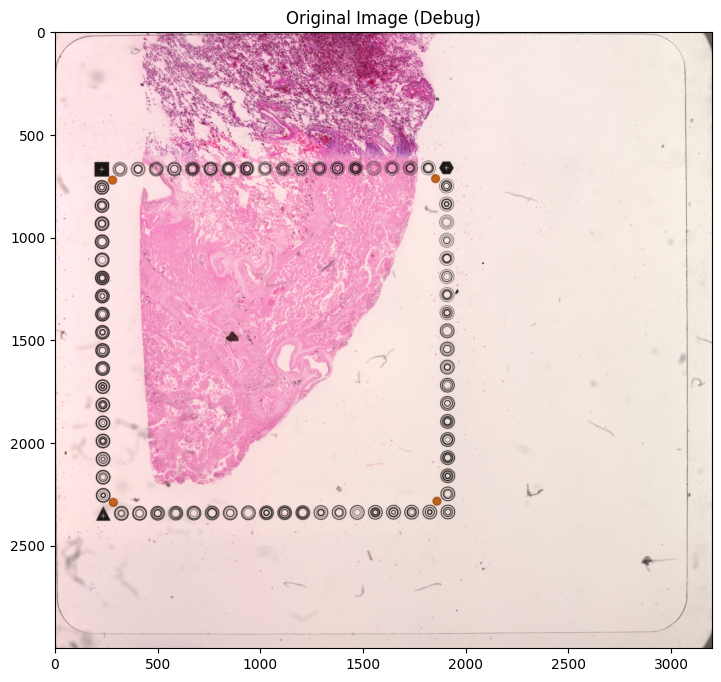

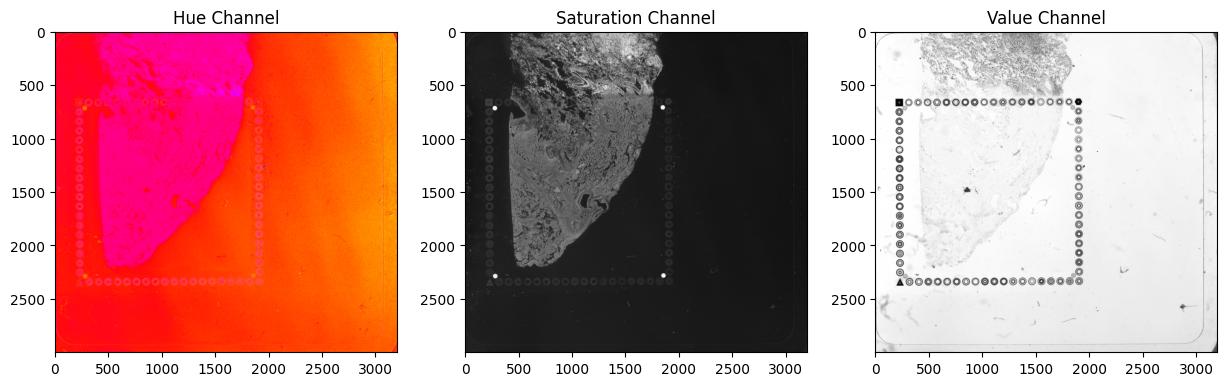

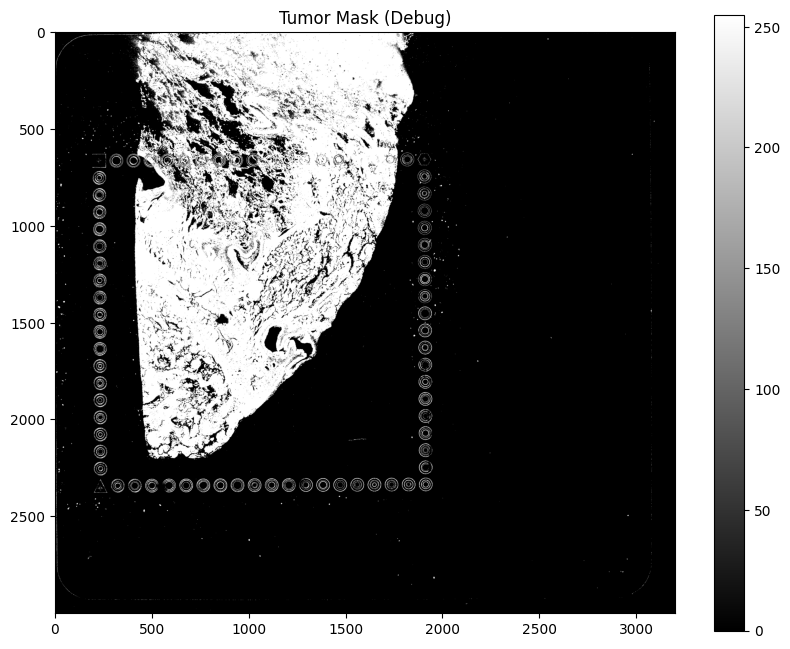

Assigned 1858 spots as Tumor based on color segmentation.
Pseudo-label distribution: Normal=6142, Tumor=1858
Epoch 0, Loss: 0.9249
Epoch 10, Loss: 0.5464
Epoch 20, Loss: 0.5063
Epoch 30, Loss: 0.4940
Epoch 40, Loss: 0.4884
Epoch 50, Loss: 0.4810
Epoch 60, Loss: 0.4805
Epoch 70, Loss: 0.4746
Epoch 80, Loss: 0.4736
Epoch 90, Loss: 0.4696
Epoch 100, Loss: 0.4685
Epoch 110, Loss: 0.4645
Epoch 120, Loss: 0.4616
Epoch 130, Loss: 0.4572
Epoch 140, Loss: 0.4582
Epoch 150, Loss: 0.4549
Epoch 160, Loss: 0.4525
Epoch 170, Loss: 0.4480
Epoch 180, Loss: 0.4456
Epoch 190, Loss: 0.4464
Epoch 200, Loss: 0.4476
Epoch 210, Loss: 0.4440
Epoch 220, Loss: 0.4422
Epoch 230, Loss: 0.4431
Epoch 240, Loss: 0.4385
Epoch 250, Loss: 0.4404
Epoch 260, Loss: 0.4384
Epoch 270, Loss: 0.4367
Epoch 280, Loss: 0.4365
Epoch 290, Loss: 0.4371

Cluster Assignments:
                  Barcode       X_Coord       Y_Coord Cluster
0     s_008um_00583_00476  12765.476834   3687.750169  Normal
1     s_008um_00342_00208  21426.333

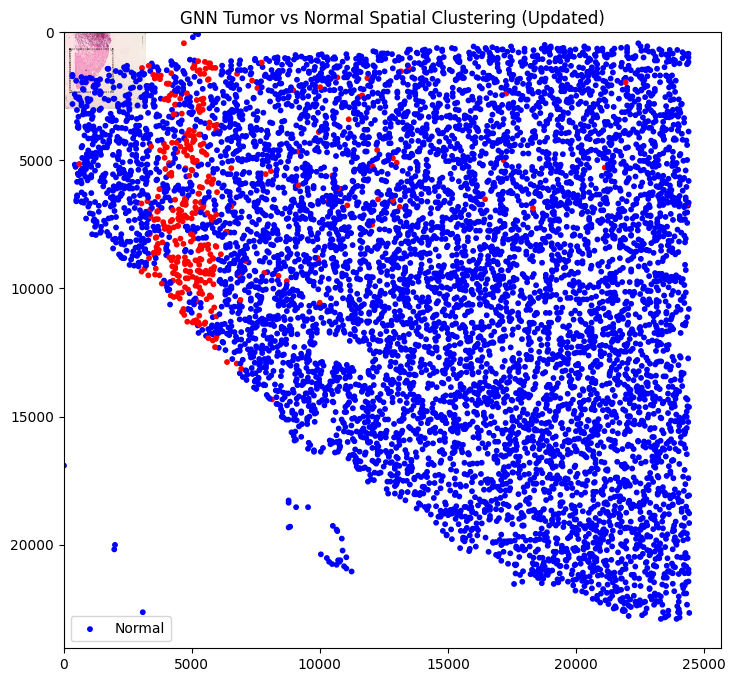

In [ ]:
# Step 1: Install PyTorch and torch-geometric dependencies in Colab
import os
import sys

# Set environment variable for Dask
os.environ['DASK_DATAFRAME__QUERY_PLANNING'] = 'True'

# Import PyTorch and torch-geometric
import torch
import torch.nn.functional as F
try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv
    from torch_geometric.utils import add_self_loops
except ImportError as e:
    raise ImportError(f"Failed to import torch_geometric modules: {e}. Ensure torch and torch-geometric are installed with compatible versions.")

import gc
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.interpolate import griddata
from mygene import MyGeneInfo
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import json

# File paths
h5_path = "/content/filtered_feature_bc_matrix.h5"
parquet_path = "/content/tissue_positions.parquet"
probe_set_path = "/content/probe_set_with_symbols.csv"  # Using CSV with gene_symbol
features_path = "/content/extracted_features.npy"
image_path = "/content/Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1_image (1).tif"

# Verify file existence
for path in [h5_path, parquet_path, probe_set_path, features_path, image_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Ensure the file is uploaded.")

# Load gene expression
adata = sc.read_10x_h5(h5_path)
adata.var_names_make_unique()

# Load spatial coordinates
spatial_df = pd.read_parquet(parquet_path)

# Align barcodes
adata.obs.index = adata.obs.index.str.split('-').str[0]
spatial_df['barcode'] = spatial_df['barcode'].str.split('-').str[0]
common_barcodes = adata.obs.index.intersection(spatial_df['barcode'])
adata = adata[adata.obs.index.isin(common_barcodes)]
spatial_df = spatial_df[spatial_df['barcode'].isin(common_barcodes)]
coords = spatial_df[['pxl_row_in_fullres', 'pxl_col_in_fullres']].values

# Debug shapes before filtering
print(f"Before filtering: adata shape = {adata.X.shape}, coords shape = {coords.shape}")

# Synchronize filtering for zero-count spots
non_zero_mask = np.asarray(adata.X.sum(axis=1)).flatten() > 0
adata = adata[non_zero_mask]
coords = coords[non_zero_mask]
print(f"After zero-count filtering: adata size = {len(adata)}, coords size = {len(coords)}")

# Step 1: Filter out non-tissue spots using the .tif image with scaling
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Failed to load image from {image_path}. Check file path and format.")
tissue_mask = img > 50
print(f"Image shape: {img.shape}")

# Use manual scale factor
scale_factor = 0.131
coords_scaled = coords * scale_factor
coords_int = coords_scaled.astype(int)
print(f"Scaled coords max: {coords_scaled.max(axis=0)}")

# Ensure coordinates are within image bounds
valid_coords = (coords_int[:, 0] >= 0) & (coords_int[:, 0] < img.shape[1]) & \
               (coords_int[:, 1] >= 0) & (coords_int[:, 1] < img.shape[0])
valid_coords_idx = np.where(valid_coords)[0]
in_tissue = np.zeros(len(coords), dtype=bool)
in_tissue[valid_coords_idx] = tissue_mask[coords_int[valid_coords_idx, 1], coords_int[valid_coords_idx, 0]]
print(f"Total spots: {len(coords)}, Valid coords: {sum(valid_coords)}, In tissue: {sum(in_tissue)}")

# Filter adata and coords using valid indices
valid_indices = np.where(in_tissue)[0]
if len(valid_indices) == 0:
    raise ValueError("No spots found within tissue region. Adjust tissue threshold or check alignment.")
if np.max(valid_indices) >= len(adata):
    raise ValueError(f"Invalid indices detected: max index {np.max(valid_indices)} exceeds adata size {len(adata)}. Check coordinate scaling.")
adata = adata[valid_indices]
coords = coords[valid_indices]
print(f"Filtered to {len(adata)} spots within tissue region.")

# Subsample spots (if needed)
n_spots = len(adata)
max_spots = 8000
if n_spots > max_spots:
    idx = np.random.choice(n_spots, max_spots, replace=False)
    adata = adata[idx]
    coords = coords[idx]
    n_spots = max_spots
    print(f"Subsampled to {max_spots} spots to reduce memory usage.")

# Recalculate coords_scaled and coords_int after subsampling
coords_scaled = coords * scale_factor
coords_int = coords_scaled.astype(int)

# Load and process probe set using gene_symbol
target_cancer_genes = ["TP53", "EGFR", "KRAS", "BRAF", "MYC"]
if os.path.exists(probe_set_path):
    probe_set = pd.read_csv(probe_set_path, comment='#')
    # Use gene_symbol column directly
    available_genes = set(probe_set['gene_symbol'])
    cancer_genes = [g for g in target_cancer_genes if g in available_genes]
    if not cancer_genes:
        print(f"Warning: No exact cancer genes {target_cancer_genes} found in probe set gene_symbol. Using all available genes.")
        cancer_genes = list(available_genes)
else:
    print(f"Warning: {probe_set_path} not found. Filtering genes directly from adata.var_names.")
    cancer_genes = target_cancer_genes

# Map dataset gene names using mygene with fallback
mg = MyGeneInfo()
try:
    gene_symbols = mg.querymany([g.split('.')[0] for g in adata.var_names], scopes='ensembl.gene', fields='symbol', species='human', returnall=True)
    symbol_map = {item['query']: item['symbol'] for item in gene_symbols['hits'] if 'symbol' in item}
    unmapped = gene_symbols.get('missing', [])
    if unmapped:
        print(f"Warning: {len(unmapped)} genes unmapped (e.g., {unmapped[0]['query']}). Using partial mapping.")
except Exception as e:
    print(f"Warning: mygene query failed: {e}. Attempting to use 10x annotation.")
    symbol_map = {}
    for gene in adata.var_names:
        if gene.startswith('ENSG'):
            try:
                symbol = mg.getgene(gene, fields='symbol')['symbol']
                symbol_map[gene] = symbol
            except:
                symbol_map[gene] = gene
        else:
            symbol_map[gene] = gene

# Avoid ImplicitModificationWarning by copying adata
adata = adata.copy()
adata.var['gene_symbol'] = [symbol_map.get(g, g) for g in adata.var_names]
mapped_cancer_genes = [g for g in adata.var_names if adata.var['gene_symbol'][g] in cancer_genes]
mapped_cancer_genes = list(set(mapped_cancer_genes))

if not mapped_cancer_genes:
    print(f"Warning: No cancer genes {cancer_genes} found in dataset. Using top highly variable genes.")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=1000, subset=True)
    mapped_cancer_genes = adata.var_names
else:
    adata = adata[:, mapped_cancer_genes]

gene_expr = adata.X.toarray()
gene_expr = np.where(np.isfinite(gene_expr), gene_expr, 0)
del adata.X
gc.collect()

# Load CNN features
cnn_features = np.load(features_path)
print(f"Loaded CNN features shape: {cnn_features.shape}")

# Adjust CNN features and patch coordinates
n_original_patches = min(462, cnn_features.shape[0])
if cnn_features.shape[0] < 462:
    print(f"Warning: Only {cnn_features.shape[0]} CNN features found. Adjusting patch coordinates to match.")
    patch_coords = np.array([[i * 448, j * 448] for i in range(cnn_features.shape[0] // 31 + 1) for j in range(31)], dtype=np.float32)[:cnn_features.shape[0]]
else:
    patch_coords = np.array([[i * 448, j * 448] for i in range(15) for j in range(31)], dtype=np.float32)[:n_original_patches]

if cnn_features.shape[0] == len(patch_coords):
    spot_features = griddata(patch_coords, cnn_features, coords, method='nearest')
else:
    print(f"Warning: CNN features ({cnn_features.shape[0]}) and patch coordinates ({len(patch_coords)}) mismatch. Using subset of coords.")
    spot_features = np.zeros((coords.shape[0], cnn_features.shape[1]))
    valid_patch_coords = patch_coords[:cnn_features.shape[0]]
    spot_features = griddata(valid_patch_coords, cnn_features, coords, method='nearest', fill_value=0)

spot_features = np.nan_to_num(spot_features, nan=0.0).astype(np.float32)
del cnn_features, patch_coords
gc.collect()

# Combine features
scaler = StandardScaler()
gene_expr_scaled = scaler.fit_transform(gene_expr).astype(np.float32)
combined_features = np.hstack((spot_features, gene_expr_scaled))
n_cnn_features = spot_features.shape[1]
n_gene_features = gene_expr_scaled.shape[1]
print(f"Combined features shape: {combined_features.shape}, CNN: {n_cnn_features}, Genes: {n_gene_features}")

# Dynamically adjust GCN input dimension
input_dim = n_cnn_features + n_gene_features

# Build graph with k-NN
k = 10
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='euclidean').fit(coords)
distances, indices = nbrs.kneighbors(coords)
edge_list = []
for i in range(n_spots):
    for j_idx, dist in zip(indices[i][1:], distances[i][1:]):
        if dist < 50:
            edge_list.append([i, j_idx])
            edge_list.append([j_idx, i])
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
del distances, indices, edge_list
gc.collect()

# Create sparse adjacency matrix
adj_indices = edge_index
adj_values = torch.ones(adj_indices.shape[1], dtype=torch.float)
adj = torch.sparse_coo_tensor(adj_indices, adj_values, (n_spots, n_spots))
del adj_indices, adj_values
gc.collect()

# Create graph data
x = torch.tensor(combined_features, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)
data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=n_spots)
del combined_features, edge_index
gc.collect()

# Define GCN for binary classification
class GCN(torch.nn.Module):
    def __init__(self, input_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, 128)
        self.conv2 = GCNConv(128, 64)
        self.conv3 = GCNConv(64, 2)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Step 2: Refine pseudo-labels with color-based segmentation
img_rgb = cv2.imread(image_path)
if img_rgb is None:
    raise ValueError(f"Failed to load image from {image_path}. Check file path and format.")

# Debug: Display original image
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
plt.title("Original Image (Debug)")
plt.show()

# Convert to HSV and debug channels
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2HSV)

# Debug: Display HSV channels separately
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_hsv[:, :, 0], cmap='hsv')
axes[0].set_title("Hue Channel")
axes[1].imshow(img_hsv[:, :, 1], cmap='gray')
axes[1].set_title("Saturation Channel")
axes[2].imshow(img_hsv[:, :, 2], cmap='gray')
axes[2].set_title("Value Channel")
plt.show()

# Adjusted HSV range for pink (tumor)
lower_pink = np.array([150, 40, 40])  # Hue 150-170 (pink), relaxed S and V
upper_pink = np.array([170, 255, 255])
tumor_mask = cv2.inRange(img_hsv, lower_pink, upper_pink)

# Debug: Display tumor mask to verify segmentation
plt.figure(figsize=(10, 8))
plt.imshow(tumor_mask, cmap='gray')
plt.title("Tumor Mask (Debug)")
plt.colorbar()
plt.show()

pseudo_labels = np.zeros(len(coords), dtype=int)
coords_int = coords_scaled.astype(int)
valid_coords = (coords_int[:, 0] >= 0) & (coords_int[:, 0] < tumor_mask.shape[1]) & \
               (coords_int[:, 1] >= 0) & (coords_int[:, 1] < tumor_mask.shape[0])
valid_coords_idx = np.where(valid_coords)[0]
pseudo_labels[valid_coords_idx] = tumor_mask[coords_int[valid_coords_idx, 1], coords_int[valid_coords_idx, 0]] > 0
print(f"Assigned {sum(pseudo_labels)} spots as Tumor based on color segmentation.")
print(f"Pseudo-label distribution: Normal={np.sum(pseudo_labels == 0)}, Tumor={np.sum(pseudo_labels == 1)}")

# Check if any tumor spots are detected
if sum(pseudo_labels) == 0:
    print("Warning: No tumor spots detected. Falling back to intensity-based thresholding.")
    # Fallback: Use intensity thresholding on the value channel
    value_channel = img_hsv[:, :, 2]
    tumor_mask = value_channel > 200  # Adjust threshold as needed
    plt.figure(figsize=(10, 8))
    plt.imshow(tumor_mask, cmap='gray')
    plt.title("Fallback Tumor Mask (Intensity-Based)")
    plt.colorbar()
    plt.show()
    pseudo_labels = np.zeros(len(coords), dtype=int)
    pseudo_labels[valid_coords_idx] = tumor_mask[coords_int[valid_coords_idx, 1], coords_int[valid_coords_idx, 0]]
    print(f"Assigned {sum(pseudo_labels)} spots as Tumor using intensity-based thresholding.")
    print(f"Pseudo-label distribution (fallback): Normal={np.sum(pseudo_labels == 0)}, Tumor={np.sum(pseudo_labels == 1)}")

# Convert to tensor
y = torch.tensor(pseudo_labels, dtype=torch.long)

# Train GCN with binary classification
model = GCN(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out, y)
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(300):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Predict clusters
model.eval()
with torch.no_grad():
    pred = model(data).argmax(dim=1).numpy()

# Create output table
results_df = pd.DataFrame({
    'Barcode': adata.obs.index,
    'X_Coord': coords[:, 0],
    'Y_Coord': coords[:, 1],
    'Cluster': ['Normal' if p == 0 else 'Tumor' for p in pred]
})
print("\nCluster Assignments:")
print(results_df)

# Step 3: Test and validate with updated plot
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB), extent=[0, img_rgb.shape[1], img_rgb.shape[0], 0])
plt.scatter(coords[:, 0], coords[:, 1], c=['blue' if p == 0 else 'red' for p in pred], s=10, label='Spots')
plt.title("GNN Tumor vs Normal Spatial Clustering (Updated)")
plt.legend(['Normal', 'Tumor'])
plt.savefig("updated_clustering.png")
plt.show()

# Save outputs
np.save("gnn_embeddings.npy", model(data).detach().numpy())
np.save("cluster_labels.npy", pred)
results_df.to_csv("cluster_assignments.csv", index=False)

In [ ]:
import pandas as pd

# Define the file path
file_path = "/content/Visium_HD_Human_Lung_Cancer_Fixed_Frozen_probe_set.csv"

# Define the gene ID to search
target_gene_id = "ENSG00000146648"

# Open the file and search line-by-line for the gene ID
found = False
with open(file_path, 'r') as file:
    for line_number, line in enumerate(file, start=1):
        if target_gene_id in line:
            print(f"Found at line {line_number}: {line.strip()}")
            found = True

if not found:
    print(f"{target_gene_id} not found in {file_path}")


Found at line 25338: ENSG00000146648,CCTATTCCGTTACACACTTTGCGGCAAGGCCCTTCGCACTTCTTACACTT,ENSG00000146648|EGFR|00c8796,TRUE,spliced
Found at line 25339: ENSG00000146648,GGTGTCCTTGCACGTGGCTTCGTCTCGGAATTTGCGGCAGACCAGGCAGT,ENSG00000146648|EGFR|11da0cb,TRUE,unspliced
Found at line 25340: ENSG00000146648,TTCCTGTGGATCCAGAGGAGGAGTATGTGTGAAGGAGTCACCCCTAAATG,ENSG00000146648|EGFR|310e7ef,TRUE,spliced


In [ ]:
pip install squidpy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.6/183.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import scanpy as sc

path_to_h5 = "/content/filtered_feature_bc_matrix.h5"

# Load the H5 file with genome GRCh38
try:
    adata = sc.read_10x_h5(path_to_h5, genome="GRCh38")
    adata.var_names_make_unique()  # Fix duplicate variable names
    print("H5 file loaded successfully.")
    print(f"Number of genes in adata: {len(adata.var_names)}")
    print(f"First few gene IDs in adata: {adata.var_names[:5]}")
except Exception as e:
    print(f"Failed to load H5 file: {e}")
    exit(1)

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


H5 file loaded successfully.
Number of genes in adata: 18085
First few gene IDs in adata: Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1'], dtype='object')


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
import scanpy as sc
import pandas as pd
import os
import h5py

# User-defined paths (update these with your actual file paths)
path_to_h5 = "/content/filtered_feature_bc_matrix.h5"  # Path to feature-barcode matrix H5
path_to_csv = "/content/probe_set_with_symbols.csv"  # Path to the updated probe set CSV with gene_symbol

# Define target cancer genes (we'll match by gene symbol now)
target_cancer_genes = {
    "TP53": "ENSG00000141510",
    "EGFR": "ENSG00000146648",
    "KRAS": "ENSG00000133703",
    "BRAF": "ENSG00000157764",
    "MYC": "ENSG00000136997"
}
target_gene_symbols = list(target_cancer_genes.keys())  # We'll match by gene symbols: TP53, EGFR, etc.

# Step 1: Verify the .h5 file exists
if not os.path.isfile(path_to_h5):
    print(f"Error: {path_to_h5} does not exist.")
    exit(1)

# Step 2: Verify the CSV file exists
if not os.path.isfile(path_to_csv):
    print(f"Error: {path_to_csv} does not exist.")
    exit(1)

# Step 3: Inspect H5 file structure
print("Inspecting H5 file structure:")
with h5py.File(path_to_h5, "r") as f:
    print("Available datasets:", list(f.keys()))
    for fabio in f.keys():
        print(f"\nContents of {fabio}:", list(f[fabio].keys()))

# Step 4: Load the .h5 file with specified genome
adata = None
try:
    print("\nTrying genome: GRCh38")
    adata = sc.read_10x_h5(path_to_h5, genome="GRCh38")
    adata.var_names_make_unique()  # Fix duplicate variable names
    print("H5 file loaded successfully.")
    print(f"Number of genes in adata: {len(adata.var_names)}")
    print(f"First few gene IDs in adata: {adata.var_names[:5]}")
except Exception as e:
    print(f"Failed to load with genome GRCh38: {e}")
    exit(1)

# Check if adata was loaded
if adata is None:
    print("Error: Could not load H5 file with specified genome. Please check the file structure.")
    exit(1)

# Step 5: Load and process probe set
try:
    probe_set = pd.read_csv(path_to_csv, sep=",", comment="#")
    print("Probe set CSV loaded successfully.")
    print("Columns in probe_set:", probe_set.columns.tolist())
except Exception as e:
    print(f"Error loading CSV: {e}")
    exit(1)

# Step 6: Debug gene_symbol presence in probe set
print("\nDebugging cancer gene presence in probe set (using gene_symbol):")
for gene in target_gene_symbols:
    ensembl_id = target_cancer_genes[gene]
    if gene in probe_set["gene_symbol"].values:
        status = probe_set[probe_set["gene_symbol"] == gene]["included"].iloc[0] if "included" in probe_set.columns else "N/A"
        print(f"{gene} ({ensembl_id}) in probe set (gene_symbol), included: {status}")
    else:
        print(f"{gene} ({ensembl_id}) not found in probe set gene_symbol column.")

# Step 7: Filter included probes (if 'included' column exists)
if "included" in probe_set.columns:
    included_probes = probe_set[probe_set["included"] == True]
else:
    included_probes = probe_set  # If no 'included' column, use all probes
    print("Warning: 'included' column not found in probe_set. Using all probes.")

# Step 8: Check for cancer genes in probe set (using gene_symbol)
cancer_genes_in_probe = [
    gene for gene in target_gene_symbols
    if gene in included_probes["gene_symbol"].values
]

if not cancer_genes_in_probe:
    print("Warning: No exact cancer genes found in included probes (using gene_symbol). Using all available genes.")
    selected_genes = adata.var_names  # Fallback to all genes
else:
    print(f"Cancer genes found in included probes (using gene_symbol): {cancer_genes_in_probe}")
    selected_genes = cancer_genes_in_probe  # Use the gene symbols directly

# Step 9: Debug cancer gene presence in adata (check if gene symbols match adata.var_names)
print("\nDebugging cancer gene presence in adata (using gene_symbol):")
for gene in target_gene_symbols:
    print(f"{gene} in adata: {'Yes' if gene in adata.var_names else 'No'}")

# Step 10: Check for cancer genes in adata and subset
cancer_genes_in_adata = [
    gene for gene in target_gene_symbols
    if gene in adata.var_names
]

if not cancer_genes_in_adata:
    print("Warning: No cancer genes found in adata (using gene_symbol). Proceeding with all genes.")
    adata_subset = adata
else:
    print(f"Cancer genes found in adata (using gene_symbol): {cancer_genes_in_adata}")
    adata_subset = adata[:, [g for g in adata.var_names if g in cancer_genes_in_adata]]

print(f"Number of genes in subset: {adata_subset.shape[1]}")
print("Proceeding with analysis using the selected genes.")

Inspecting H5 file structure:
Available datasets: ['matrix']

Contents of matrix: ['barcodes', 'data', 'features', 'indices', 'indptr', 'shape']

Trying genome: GRCh38


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


H5 file loaded successfully.
Number of genes in adata: 18085
First few gene IDs in adata: Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1'], dtype='object')
Probe set CSV loaded successfully.
Columns in probe_set: ['gene_id', 'probe_seq', 'probe_id', 'included', 'region', 'gene_symbol']

Debugging cancer gene presence in probe set (using gene_symbol):
TP53 (ENSG00000141510) in probe set (gene_symbol), included: True
EGFR (ENSG00000146648) in probe set (gene_symbol), included: True
KRAS (ENSG00000133703) in probe set (gene_symbol), included: True
BRAF (ENSG00000157764) in probe set (gene_symbol), included: True
MYC (ENSG00000136997) in probe set (gene_symbol), included: True
Cancer genes found in included probes (using gene_symbol): ['TP53', 'EGFR', 'KRAS', 'BRAF', 'MYC']

Debugging cancer gene presence in adata (using gene_symbol):
TP53 in adata: Yes
EGFR in adata: Yes
KRAS in adata: Yes
BRAF in adata: Yes
MYC in adata: Yes
Cancer genes found in adata (using gene_symbol): ['TP53'

In [ ]:
import os
os.environ['DASK_DATAFRAME__QUERY_PLANNING'] = 'True'

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.interpolate import griddata
from mygene import MyGeneInfo
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# File paths
h5_path = "/content/filtered_feature_bc_matrix.h5"
parquet_path = "/content/tissue_positions.parquet"
probe_set_path = "/content/Visium_HD_Human_Lung_Cancer_Fixed_Frozen_probe_set_updated.csv"
features_path = "/content/extracted_features.npy"

# Load gene expression
adata = sc.read_10x_h5(h5_path)
adata.var_names_make_unique()

# Load spatial coordinates
spatial_df = pd.read_parquet(parquet_path)
adata.obs.index = adata.obs.index.str.split('-').str[0]
spatial_df['barcode'] = spatial_df['barcode'].str.split('-').str[0]
common_barcodes = adata.obs.index.intersection(spatial_df['barcode'])
adata = adata[adata.obs.index.isin(common_barcodes)]
coords = spatial_df[spatial_df['barcode'].isin(common_barcodes)][['pxl_row_in_fullres', 'pxl_col_in_fullres']].values

# Remove zero-count spots
adata = adata[adata.X.sum(axis=1) > 0]

# Subsample (for performance)
n_spots = len(adata)
max_spots = 8000
if n_spots > max_spots:
    idx = np.random.choice(n_spots, max_spots, replace=False)
    adata = adata[idx]
    coords = coords[idx]
    n_spots = max_spots
    print(f"Subsampled to {max_spots} spots to reduce memory usage.")

# Load probe set and extract cancer gene symbols
target_cancer_genes = ["TP53", "EGFR", "KRAS", "BRAF", "MYC"]
probe_set = pd.read_csv(probe_set_path, comment='#')
gene_mapping = {row['gene_id']: row['probe_id'].split('|')[1] for _, row in probe_set.iterrows() if '|' in row['probe_id'] and row['included'] == 'TRUE'}
available_genes = set(gene_mapping.values())
cancer_genes = [g for g in target_cancer_genes if g in available_genes]
if not cancer_genes:
    print(f"Warning: No exact cancer genes {target_cancer_genes} found in probe set. Using all available genes.")
    cancer_genes = list(available_genes)

# Map gene symbols in dataset using mygene
mg = MyGeneInfo()
try:
    gene_symbols = mg.querymany(list(adata.var_names), scopes='ensembl.gene', fields='symbol', species='human', returnall=True)
    symbol_map = {item['query']: item['symbol'] for item in gene_symbols['hits'] if 'symbol' in item}
except Exception as e:
    print(f"Warning: mygene query failed: {e}. Attempting fallback.")
    symbol_map = {gene: gene for gene in adata.var_names}

adata.var['gene_symbol'] = [symbol_map.get(g, g) for g in adata.var_names]
mapped_cancer_genes = [g for g in adata.var_names if adata.var['gene_symbol'][g] in cancer_genes]
mapped_cancer_genes = list(set(mapped_cancer_genes))

if not mapped_cancer_genes:
    print(f"Warning: No cancer genes {cancer_genes} found in dataset. Using top highly variable genes.")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=1000, subset=True)
    mapped_cancer_genes = adata.var_names
else:
    adata = adata[:, mapped_cancer_genes]

gene_expr = adata.X.toarray()
gene_expr = np.where(np.isfinite(gene_expr), gene_expr, 0)
del adata.X
gc.collect()

# Load CNN features
cnn_features = np.load(features_path)
print(f"Loaded CNN features shape: {cnn_features.shape}")

# Match patch coordinates to CNN feature count
n_original_patches = cnn_features.shape[0]
patch_coords = np.array([[i * 448, j * 448] for i in range(n_original_patches // 31 + 1) for j in range(31)], dtype=np.float32)[:n_original_patches]

# Interpolate CNN features onto spatial coordinates
spot_features = griddata(patch_coords, cnn_features, coords, method='nearest', fill_value=0)
spot_features = np.nan_to_num(spot_features, nan=0.0).astype(np.float32)

# Combine CNN + gene features
scaler = StandardScaler()
gene_expr_scaled = scaler.fit_transform(gene_expr).astype(np.float32)
combined_features = np.hstack((spot_features, gene_expr_scaled))
n_cnn_features = spot_features.shape[1]
n_gene_features = gene_expr_scaled.shape[1]
input_dim = n_cnn_features + n_gene_features
print(f"Combined features shape: {combined_features.shape}, CNN: {n_cnn_features}, Genes: {n_gene_features}")

# Build graph with kNN
k = 10
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
distances, indices = nbrs.kneighbors(coords)
edge_list = []
for i in range(n_spots):
    for j_idx, dist in zip(indices[i][1:], distances[i][1:]):
        if dist < 50:
            edge_list.append([i, j_idx])
            edge_list.append([j_idx, i])
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# Prepare GNN input
x = torch.tensor(combined_features, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)
data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=n_spots)

# GNN model
class GNN(torch.nn.Module):
    def __init__(self, input_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, 128)
        self.conv2 = GCNConv(128, 64)
        self.conv3 = GCNConv(64, 2)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize and train model
model = GNN(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Pseudo-labels using spatial density
spatial_density = np.sum((coords[:, None] - coords) ** 2, axis=2).mean(axis=1)
threshold = np.percentile(spatial_density, 90)
pseudo_labels = (spatial_density > threshold).astype(int)
y = torch.tensor(pseudo_labels, dtype=torch.long)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out, y)
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(300):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Predict labels
model.eval()
with torch.no_grad():
    pred = model(data).argmax(dim=1).numpy()

# Prepare output
results_df = pd.DataFrame({
    'Barcode': adata.obs.index,
    'X_Coord': coords[:, 0],
    'Y_Coord': coords[:, 1],
    'Cluster': ['Tumor' if p == 1 else 'Normal' for p in pred]
})
print("\nCluster Assignments:")
print(results_df)

# Save outputs
np.save("gnn_embeddings.npy", model(data).detach().numpy())
np.save("cluster_labels.npy", pred)
results_df.to_csv("cluster_assignments.csv", index=False)

# 📊 Plot results
plt.figure(figsize=(10, 10))
sns.scatterplot(
    x=results_df["X_Coord"],
    y=-results_df["Y_Coord"],  # invert for display
    hue=results_df["Cluster"],
    palette={"Tumor": "red", "Normal": "blue"},
    s=18, alpha=0.8
)
plt.title("GNN Tumor vs Normal Spatial Clustering")
plt.axis("off")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("gnn_spatial_clusters.png")
plt.show()


In [ ]:
pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
# Assuming adata is already loaded
print("All gene names in adata.var_names:")
print(list(adata.var_names))

All gene names in adata.var_names:
['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15', 'AGRN', 'RNF223', 'C1orf159', 'TTLL10', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6', 'C1QTNF12', 'UBE2J2', 'SCNN1D', 'ACAP3', 'PUSL1', 'INTS11', 'CPTP', 'TAS1R3', 'DVL1', 'MXRA8', 'AURKAIP1', 'CCNL2', 'ANKRD65', 'TMEM88B', 'VWA1', 'ATAD3C', 'ATAD3B', 'ATAD3A', 'TMEM240', 'SSU72', 'FNDC10', 'MIB2', 'MMP23B', 'CDK11B', 'CDK11A', 'NADK', 'GNB1', 'CALML6', 'TMEM52', 'CFAP74', 'GABRD', 'PRKCZ', 'FAAP20', 'SKI', 'RER1', 'PEX10', 'PLCH2', 'PANK4', 'HES5', 'TNFRSF14', 'PRXL2B', 'MMEL1', 'ACTRT2', 'PRDM16', 'ARHGEF16', 'MEGF6', 'TPRG1L', 'WRAP73', 'TP73', 'CCDC27', 'SMIM1', 'LRRC47', 'CEP104', 'DFFB', 'C1orf174', 'AJAP1', 'NPHP4', 'KCNAB2', 'CHD5', 'RNF207', 'ICMT', 'GPR153', 'ACOT7', 'HES2', 'ESPN', 'TNFRSF25', 'PLEKHG5', 'NOL9', 'TAS1R1', 'ZBTB48', 'KLHL21', 'PHF13', 'THAP3', 'DNAJC11', 'CAMTA1', 'VAMP3', 'PER3', 'UTS2', 'TNFRSF9', 'ERRFI1', 'SLC45A1', 'RERE', 'ENO1', 'CA6', 'SLC2A7', 'SLC2A5', 

In [ ]:
import pandas as pd

# Load the probe set CSV with adjustments
# Try different delimiters (e.g., tab '\t', comma ',', or semicolon ';')
# Skip rows if the file has metadata (adjust skiprows as needed)
probe_df = pd.read_csv('/content/Visium_HD_Human_Lung_Cancer_Fixed_Frozen_probe_set_updated.csv',
                       delimiter=',',  # Adjust to '\t' or ';' if needed
                       skiprows=0,    # Skip metadata rows if present
                       on_bad_lines='skip')  # Skip malformed lines

# Function to extract gene symbol from probe_id
def extract_gene_symbol(probe_id):
    if isinstance(probe_id, str) and '|' in probe_id:
        return probe_id.split('|')[1]  # Returns the second part (gene symbol)
    return probe_id  # Return as is if no | is found

# Apply the function to the probe_id column
probe_df['gene_symbol'] = probe_df['probe_id'].apply(extract_gene_symbol)

# Display or save the result
print(probe_df[['probe_id', 'gene_symbol']])
# To save: probe_df.to_csv('probe_set_with_symbols.csv', index=False)

                                            probe_id gene_symbol
0                     ENSG00000000003|TSPAN6|8eab823      TSPAN6
1                     ENSG00000000003|TSPAN6|9d7fe51      TSPAN6
2                     ENSG00000000003|TSPAN6|d2b5833      TSPAN6
3                       ENSG00000000005|TNMD|7790621        TNMD
4                       ENSG00000000005|TNMD|923f04b        TNMD
...                                              ...         ...
54575  DEPRECATED_ENSG00000278803|AC236972.4|53ec843  AC236972.4
54576  DEPRECATED_ENSG00000278803|AC236972.4|b4ceb8b  AC236972.4
54577     DEPRECATED_ENSG00000283967|TAF11L8|5800ed2     TAF11L8
54578       DEPRECATED_ENSG00000284873|OOSP1|b83341e       OOSP1
54579  DEPRECATED_ENSG00000285687|AC134684.8|e8ced10  AC134684.8

[54580 rows x 2 columns]


In [ ]:
import pandas as pd

# Load the probe set CSV with adjustments
probe_df = pd.read_csv('/content/Visium_HD_Human_Lung_Cancer_Fixed_Frozen_probe_set_updated.csv',
                       delimiter=',',
                       skiprows=0,
                       on_bad_lines='skip')

# Function to extract gene symbol from probe_id
def extract_gene_symbol(probe_id):
    if isinstance(probe_id, str) and '|' in probe_id:
        return probe_id.split('|')[1]
    return probe_id

# Apply the function to the probe_id column
probe_df['gene_symbol'] = probe_df['probe_id'].apply(extract_gene_symbol)

# Save the result to a new CSV file
probe_df.to_csv('probe_set_with_symbols.csv', index=False)

# Display the result
print(probe_df[['probe_id', 'gene_symbol']])

                                            probe_id gene_symbol
0                     ENSG00000000003|TSPAN6|8eab823      TSPAN6
1                     ENSG00000000003|TSPAN6|9d7fe51      TSPAN6
2                     ENSG00000000003|TSPAN6|d2b5833      TSPAN6
3                       ENSG00000000005|TNMD|7790621        TNMD
4                       ENSG00000000005|TNMD|923f04b        TNMD
...                                              ...         ...
54575  DEPRECATED_ENSG00000278803|AC236972.4|53ec843  AC236972.4
54576  DEPRECATED_ENSG00000278803|AC236972.4|b4ceb8b  AC236972.4
54577     DEPRECATED_ENSG00000283967|TAF11L8|5800ed2     TAF11L8
54578       DEPRECATED_ENSG00000284873|OOSP1|b83341e       OOSP1
54579  DEPRECATED_ENSG00000285687|AC134684.8|e8ced10  AC134684.8

[54580 rows x 2 columns]


In [ ]:
import pandas as pd
import anndata as ad

# Load the probe set CSV with gene symbols
probe_df = pd.read_csv('/content/probe_set_with_symbols.csv')

# Define the target genes (tumor-related)
target_genes = {
    'TP53': 'ENSG00000141510',
    'EGFR': 'ENSG00000146648',
    'KRAS': 'ENSG00000133703',
    'BRAF': 'ENSG00000157764',
    'MYC': 'ENSG00000136997'
}

# Extract gene symbols and categorize as tumor if they match target genes
probe_df['category'] = probe_df['gene_symbol'].apply(
    lambda x: 'tumor' if x in target_genes.keys() else 'non-tumor'
)

# Get the list of tumor-related gene symbols
tumor_gene_names = probe_df[probe_df['category'] == 'tumor']['gene_symbol'].unique().tolist()

# Load your adata object (adjust loading as needed)
# adata = ad.read_h5ad('your_adata_file.h5ad')

# Check current gene names in adata
print("Genes in adata.var_names before mapping:", adata.var_names)

# Filter adata to include only the tumor-related genes present in both adata.var_names and tumor_gene_names
common_tumor_genes = [gene for gene in tumor_gene_names if gene in adata.var_names]

if not common_tumor_genes:
    print("Warning: No tumor-related genes found in adata.var_names. Check naming consistency.")
else:
    print("Found tumor-related genes in adata:", common_tumor_genes)
    # Subset adata to include only the tumor-related genes
    adata = adata[:, adata.var_names.isin(common_tumor_genes)].copy()

# Proceed with analysis
print(f"Number of tumor-related genes in subset after mapping: {adata.shape[1]}")

# Optionally, save the updated probe_df with the category column
probe_df.to_csv('probe_set_with_categories.csv', index=False)

Genes in adata.var_names before mapping: Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'RNF223', 'C1orf159',
       ...
       'MT-ND2', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=18085)
Found tumor-related genes in adata: ['KRAS', 'MYC', 'TP53', 'EGFR', 'BRAF']
Number of tumor-related genes in subset after mapping: 5
